## Build A Basic ChatBot with LangGraph (Graph API)

![basic-chat-bot](./flowcharts/1-basic-chat-bot.svg)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

### Define State Definition

In [2]:
class State(TypedDict):
    # Messages have the type "list", the 'add_messages' function
    # in the annotaion defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

load_dotenv()

True

### Initialize models : method 1

In [5]:
model = ChatGroq(model="qwen3.6-27b")

In [6]:
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x110dd57f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x110dd6510>, model_name='qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Initialize models : method 2

In [7]:
model = init_chat_model("groq:qwen/qwen3.6-27b")

### Node Functionality

In [8]:
def chatbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}

### Define Graph State

In [9]:
graph_builder = StateGraph(State)

### Adding node

In [10]:
graph_builder.add_node("llmchatbot", chatbot)

### Adding edges

In [11]:
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

### Compile the complete graph

In [12]:
graph = graph_builder.compile()

### Visualize the graph

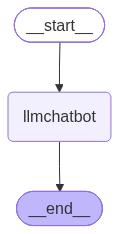

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    raise e

### Pass the Human Message

In [14]:
from langchain.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage("Hi")]})

print(response["messages"][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:** The user simply said "Hi". This is a standard greeting.
2.  **Identify Intent:** The user is initiating a conversation. No specific question or request is made.
3.  **Determine Response Strategy:** 
   - Acknowledge the greeting politely
   - Offer assistance
   - Keep it open-ended to encourage the user to share what they need
   - Maintain a friendly, professional tone
4.  **Draft Response (Internal):** Hello! How can I assist you today? Whether you have a question, need help with something, or just want to chat, I'm here for you.
5.  **Refine Response:** Keep it concise and welcoming. "Hello! How can I help you today?" is simple and effective. I'll add a slight touch of warmth without being overly verbose.
6.  **Final Output Generation:** Match the refined response.✅
</think>

Hello! How can I help you today? 😊


### Print response with `stream()`

In [15]:
for event in graph.stream({"messages": [HumanMessage("Hi, how are yout ?")]}):
    for value in event.values():
        print(value["messages"][-1].content)


<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - User says: "Hi, how are yout ?"
   - Note: There's a typo ("yout" instead of "you"), but the meaning is clear.
   - Intent: Greeting and asking about my well-being/status.

2.  **Identify Key Requirements:**
   - Acknowledge the greeting
   - Respond to the question about how I'm doing
   - Keep it friendly and conversational
   - Note that I'm an AI, so I don't have feelings, but I can respond positively
   - Ask how they're doing in return

3.  **Formulate Response (Mental Refinement):**
   - "Hi! I'm doing well, thanks for asking. I'm here and ready to help you with whatever you need. How are you doing today?"
   - Check tone: Friendly, professional, appropriate
   - Check accuracy: Acknowledges AI nature implicitly by focusing on readiness to help
   - Check grammar/typos: Clean and correct

4.  **Final Output Generation:** (Matches the refined version)
   - "Hi! I'm doing well, thanks for asking. I'm here and re